# Notebook A: 100-Robot Loop Without Faults

This notebook runs the final-success implementation for 100 trials with NeuroKin off and on, using the clean control loop only.

In [5]:
import json
import logging
import os
import random
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pybullet as p
import pybullet_data
import torch
import torch.nn as nn

NUM_ROBOTS = 100
SEED = 42
OUT_DIR = Path.cwd() / "phase2_clean_100_no_fault"
OUT_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("phase2_clean")


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_project_root() -> Path:
    candidates = [
        os.environ.get("ROBOT_SELF_MODELLING_ROOT"),
        "/content/drive/MyDrive/robot_self_modelling",
        "/content/robot_self_modelling",
        os.path.expanduser("~/robot_self_modelling"),
        os.path.join(os.path.expanduser("~"), "Downloads", "robot_self_modelling"),
        str(Path.cwd()),
        str(Path.cwd().parent),
    ]
    for root in candidates:
        if not root:
            continue
        root_path = Path(root).expanduser().resolve()
        urdf_candidate = root_path / "RobotArmURDF" / "4dof_1st" / "urdf" / "4dof_1st.urdf"
        if urdf_candidate.exists():
            return root_path
    return Path.cwd().resolve()


ROOT_DIR = find_project_root()
URDF_PATH = ROOT_DIR / "RobotArmURDF" / "4dof_1st" / "urdf" / "4dof_1st.urdf"
MODEL_PATH = ROOT_DIR / "models" / "neurokin_3d_best.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
logger.info(f"ROOT_DIR: {ROOT_DIR}")
logger.info(f"URDF_PATH: {URDF_PATH}")
logger.info(f"MODEL_PATH: {MODEL_PATH}")
logger.info(f"DEVICE: {DEVICE}")


def build_camera_matrices(camera_pos, target_pos, up_vec, fov=42, aspect=1.0, near=0.1, far=100.0):
    view = p.computeViewMatrix(cameraEyePosition=camera_pos, cameraTargetPosition=target_pos, cameraUpVector=up_vec)
    proj = p.computeProjectionMatrixFOV(fov=fov, aspect=aspect, nearVal=near, farVal=far)
    return view, proj


def preprocess_image(rgb, threshold=240):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return (gray < threshold).astype(np.uint8) * 255


def load_model(model_path=MODEL_PATH):
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")
    model = NeuroKin3D().to(DEVICE)
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


class DualCameraEnv:
    def __init__(self, urdf_path, width=100, height=100, cam_dist=1.0, sim_steps=50):
        self.urdf_path = str(urdf_path)
        self.width = width
        self.height = height
        self.cam_dist = cam_dist
        self.sim_steps = sim_steps
        self.num_motor = 4
        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -9.8)
        plane = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
        p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane, basePosition=[0, 0, -0.109])
        self.robot_id = p.loadURDF(self.urdf_path, [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
        self.ee_link_index = p.getNumJoints(self.robot_id) - 1
        self.cam1_view, self.cam1_proj = build_camera_matrices([cam_dist, 0, 0], [0, 0, 0], [0, 0, 1])
        self.cam2_view, self.cam2_proj = build_camera_matrices([0, cam_dist, 0], [0, 0, 0], [0, 0, 1])

    def reset(self):
        for i in range(self.num_motor):
            p.resetJointState(self.robot_id, i, 0)
        p.stepSimulation()

    def close(self):
        p.disconnect()

    def get_gt_ee(self):
        return np.array(p.getLinkState(self.robot_id, self.ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)

    def get_joint_angles(self):
        return np.array([p.getJointState(self.robot_id, i)[0] for i in range(self.num_motor)], dtype=np.float32)

    def capture_views(self):
        img1 = p.getCameraImage(self.width, self.height, self.cam1_view, self.cam1_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        img2 = p.getCameraImage(self.width, self.height, self.cam2_view, self.cam2_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        rgb1 = np.reshape(img1[2], (self.height, self.width, 4))[:, :, :3].astype(np.uint8)
        rgb2 = np.reshape(img2[2], (self.height, self.width, 4))[:, :, :3].astype(np.uint8)
        return rgb1, rgb2

    def step(self, joint_targets):
        for i in range(self.num_motor):
            p.setJointMotorControl2(self.robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(joint_targets[i]), force=100)
        for _ in range(self.sim_steps):
            p.stepSimulation()


class PositionalEncoding2D(nn.Module):
    def __init__(self, height=100, width=100):
        super().__init__()
        y = torch.linspace(-1, 1, steps=height)
        x = torch.linspace(-1, 1, steps=width)
        gy, gx = torch.meshgrid(y, x, indexing="ij")
        self.register_buffer("grid", torch.stack([gx, gy], dim=0).unsqueeze(0))

    def forward(self, x):
        return torch.cat([x, self.grid.expand(x.size(0), -1, -1, -1)], dim=1)


class SpatialConvStream(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

    def forward(self, x):
        return self.net(x)


class NeuroKin3D(nn.Module):
    def __init__(self, image_h=100, image_w=100):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(image_h, image_w)
        self.cam1_stream = SpatialConvStream(in_channels=3)
        self.cam2_stream = SpatialConvStream(in_channels=3)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, image_h, image_w)
            feat_dim = int(np.prod(self.cam1_stream(dummy).shape[1:]))
        self.virtual_frame_proj = nn.Sequential(nn.Linear(feat_dim * 2, 512), nn.LayerNorm(512), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 7))

    def forward(self, cam1, cam2):
        cam1_spatial = self.pos_enc(cam1)
        cam2_spatial = self.pos_enc(cam2)
        f1 = self.cam1_stream(cam1_spatial).flatten(1)
        f2 = self.cam2_stream(cam2_spatial).flatten(1)
        return self.head(self.virtual_frame_proj(torch.cat([f1, f2], dim=1)))


def estimate_ee_xyz(rgb1, rgb2, model, device=DEVICE):
    mask1 = preprocess_image(rgb1)
    mask2 = preprocess_image(rgb2)
    h = int(model.pos_enc.grid.shape[2])
    w = int(model.pos_enc.grid.shape[3])
    if mask1.shape != (h, w):
        mask1 = cv2.resize(mask1, (w, h), interpolation=cv2.INTER_NEAREST)
        mask2 = cv2.resize(mask2, (w, h), interpolation=cv2.INTER_NEAREST)
    cam1 = torch.from_numpy(mask1.astype(np.float32) / 255.0)[None, None, ...].to(device)
    cam2 = torch.from_numpy(mask2.astype(np.float32) / 255.0)[None, None, ...].to(device)
    with torch.inference_mode():
        pred = model(cam1, cam2).cpu().numpy().squeeze(0)
    return pred[:3].astype(np.float32), pred[3:7].astype(np.float32) * 90.0

In [2]:
def run_single_robot_chain_baseline(urdf_path, num_stages=100, num_steps_per_stage=200, tolerance=0.01, seed=42):
    np.random.seed(seed)
    physics_client = p.connect(p.DIRECT)
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.8)
    plane = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
    p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane, basePosition=[0, 0, -0.109])
    robot_id = p.loadURDF(str(urdf_path), [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
    ee_link_index = p.getNumJoints(robot_id) - 1
    num_motor = 4
    joint_limits = []
    for i in range(num_motor):
        info = p.getJointInfo(robot_id, i)
        lower, upper = info[8], info[9]
        if lower >= upper:
            lower, upper = -np.pi / 2, np.pi / 2
        joint_limits.append((lower, upper))
    joint_limits = np.array(joint_limits, dtype=np.float32)
    lower = joint_limits[:, 0]
    upper = joint_limits[:, 1]
    ranges = upper - lower
    stage_logs = []
    successes = []
    start = time.time()
    try:
        for stage_idx in range(num_stages):
            for i in range(num_motor):
                p.resetJointState(robot_id, i, 0)
            p.stepSimulation()
            home_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
            target_pos = np.array([0.15 + (np.random.random() - 0.5) * 0.1, (np.random.random() - 0.5) * 0.2, 0.15], dtype=np.float32)
            current_commanded = home_ee.copy()
            prev_error = np.zeros(3, dtype=np.float32)
            trace = []
            stage_ok = False
            for step_idx in range(num_steps_per_stage):
                gt_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
                trace.append(gt_ee.copy())
                if np.linalg.norm(target_pos - gt_ee) <= tolerance:
                    stage_ok = True
                    break
                error = target_pos - gt_ee
                delta = 0.25 * (error - prev_error) + 0.06 * error
                delta = np.clip(delta, -0.01, 0.01)
                current_commanded = current_commanded + delta
                rest = np.array([p.getJointState(robot_id, i)[0] for i in range(num_motor)])
                joint_targets = p.calculateInverseKinematics(
                    robot_id, ee_link_index, current_commanded,
                    lowerLimits=lower.tolist(), upperLimits=upper.tolist(),
                    jointRanges=ranges.tolist(), restPoses=rest.tolist(),
                    jointDamping=[0.01] * num_motor, residualThreshold=1e-4, maxNumIterations=100,
                )
                joint_targets = np.array(joint_targets[:num_motor], dtype=np.float32)
                for i in range(num_motor):
                    p.setJointMotorControl2(robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(joint_targets[i]), force=100)
                for _ in range(50):
                    p.stepSimulation()
                prev_error = error.copy()
            stage_logs.append({"stage": f"S{stage_idx + 1}", "target": target_pos, "trace": np.array(trace), "success": stage_ok})
            successes.append(stage_ok)
    finally:
        elapsed = time.time() - start
        p.disconnect()
    return stage_logs, successes, elapsed


def run_single_robot_chain_neurokin(urdf_path, model, device, num_stages=100, num_steps_per_stage=200, est_stride=2, tolerance=0.01, seed=42):
    np.random.seed(seed)
    physics_client = p.connect(p.DIRECT)
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.8)
    plane = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
    p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane, basePosition=[0, 0, -0.109])
    robot_id = p.loadURDF(str(urdf_path), [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
    ee_link_index = p.getNumJoints(robot_id) - 1
    num_motor = 4
    joint_limits = []
    for i in range(num_motor):
        info = p.getJointInfo(robot_id, i)
        lower, upper = info[8], info[9]
        if lower >= upper:
            lower, upper = -np.pi / 2, np.pi / 2
        joint_limits.append((lower, upper))
    joint_limits = np.array(joint_limits, dtype=np.float32)
    lower = joint_limits[:, 0]
    upper = joint_limits[:, 1]
    ranges = upper - lower
    cam1_view, cam1_proj = build_camera_matrices([1.0, 0, 0], [0, 0, 0], [0, 0, 1])
    cam2_view, cam2_proj = build_camera_matrices([0, 1.0, 0], [0, 0, 0], [0, 0, 1])
    stage_logs = []
    successes = []
    start = time.time()
    try:
        for stage_idx in range(num_stages):
            for i in range(num_motor):
                p.resetJointState(robot_id, i, 0)
            p.stepSimulation()
            home_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
            target_pos = np.array([0.15 + (np.random.random() - 0.5) * 0.1, (np.random.random() - 0.5) * 0.2, 0.15], dtype=np.float32)
            current_commanded = home_ee.copy()
            prev_error = np.zeros(3, dtype=np.float32)
            est_ee_sm = None
            last_est_joints_deg = None
            trace = []
            stage_ok = False
            for step_idx in range(num_steps_per_stage):
                gt_ee = np.array(p.getLinkState(robot_id, ee_link_index, computeForwardKinematics=True)[0], dtype=np.float32)
                trace.append(gt_ee.copy())
                if np.linalg.norm(target_pos - gt_ee) <= tolerance:
                    stage_ok = True
                    break
                if step_idx % max(1, int(est_stride)) == 0:
                    img1 = p.getCameraImage(100, 100, cam1_view, cam1_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
                    img2 = p.getCameraImage(100, 100, cam2_view, cam2_proj, renderer=p.ER_TINY_RENDERER, shadow=0)
                    rgb1 = np.reshape(img1[2], (100, 100, 4))[:, :, :3].astype(np.uint8)
                    rgb2 = np.reshape(img2[2], (100, 100, 4))[:, :, :3].astype(np.uint8)
                    est_ee, est_joints_deg = estimate_ee_xyz(rgb1, rgb2, model, device)
                    est_ee_sm = est_ee if est_ee_sm is None else 0.6 * est_ee_sm + 0.4 * est_ee
                    last_est_joints_deg = est_joints_deg
                if last_est_joints_deg is None or est_ee_sm is None:
                    continue
                error = target_pos - est_ee_sm
                delta = 0.25 * (error - prev_error) + 0.06 * error
                delta = np.clip(delta, -0.01, 0.01)
                current_commanded = current_commanded + delta
                workspace_min = np.array([0.02, -0.20, 0.05], dtype=np.float32)
                workspace_max = np.array([0.30, 0.20, 0.25], dtype=np.float32)
                current_commanded = np.clip(current_commanded, workspace_min, workspace_max)
                rest = np.deg2rad(last_est_joints_deg)
                joint_targets = p.calculateInverseKinematics(
                    robot_id, ee_link_index, current_commanded,
                    lowerLimits=lower.tolist(), upperLimits=upper.tolist(),
                    jointRanges=ranges.tolist(), restPoses=rest.tolist(),
                    jointDamping=[0.01] * num_motor, residualThreshold=1e-4, maxNumIterations=100,
                )
                joint_targets = np.array(joint_targets[:num_motor], dtype=np.float32)
                for i in range(num_motor):
                    p.setJointMotorControl2(robot_id, i, controlMode=p.POSITION_CONTROL, targetPosition=float(joint_targets[i]), force=100)
                for _ in range(50):
                    p.stepSimulation()
                prev_error = error.copy()
            stage_logs.append({"stage": f"S{stage_idx + 1}", "target": target_pos, "trace": np.array(trace), "success": stage_ok})
            successes.append(stage_ok)
    finally:
        elapsed = time.time() - start
        p.disconnect()
    return stage_logs, successes, elapsed

    variant  success_rate  mean_steps  median_steps  failures     label
0  baseline          1.00       42.16          43.0         0  no_fault
1  neurokin          0.98       35.93          33.0         2  no_fault


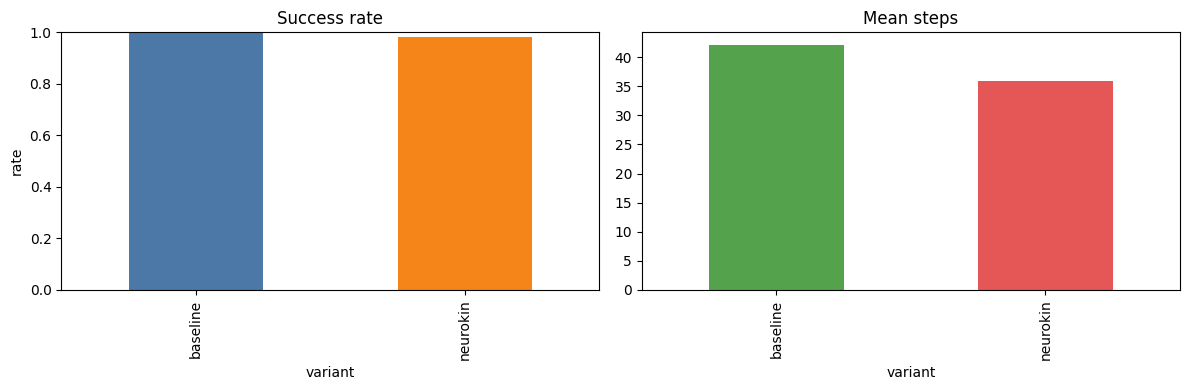

Baseline: 100.0% success in 7.58s
NeuroKin: 98.0% success in 142.45s
Reload verification passed.


In [7]:
def summarize_results(df, label):
    summary = df.groupby("variant").agg(
        success_rate=("success", "mean"),
        mean_steps=("steps", "mean"),
        median_steps=("steps", "median"),
        failures=("success", lambda s: int((~s).sum())),
    ).reset_index()
    summary["label"] = label
    return summary


model = load_model()
clean_config = {
    "num_robots": NUM_ROBOTS,
    "seed": SEED,
    "urdf_path": str(URDF_PATH),
    "model_path": str(MODEL_PATH),
    "device": str(DEVICE),
}
(OUT_DIR / "config.json").write_text(json.dumps(clean_config, indent=2))

logger.info("Running 100-trial baseline (NeuroKin off)...")
baseline_logs, baseline_successes, baseline_time = run_single_robot_chain_baseline(URDF_PATH, num_stages=NUM_ROBOTS, seed=SEED)
baseline_df = pd.DataFrame([
    {"trial": i + 1, "variant": "baseline", "success": bool(ok), "steps": len(log["trace"]), "target_x": float(log["target"][0]), "target_y": float(log["target"][1]), "target_z": float(log["target"][2])}
    for i, (log, ok) in enumerate(zip(baseline_logs, baseline_successes))
])
baseline_df.to_csv(OUT_DIR / "baseline_no_fault.csv", index=False)

logger.info("Running 100-trial NeuroKin run (NeuroKin on)...")
neurokin_logs, neurokin_successes, neurokin_time = run_single_robot_chain_neurokin(URDF_PATH, model, DEVICE, num_stages=NUM_ROBOTS, seed=SEED)
neurokin_df = pd.DataFrame([
    {"trial": i + 1, "variant": "neurokin", "success": bool(ok), "steps": len(log["trace"]), "target_x": float(log["target"][0]), "target_y": float(log["target"][1]), "target_z": float(log["target"][2])}
    for i, (log, ok) in enumerate(zip(neurokin_logs, neurokin_successes))
])
neurokin_df.to_csv(OUT_DIR / "neurokin_no_fault.csv", index=False)

results_df = pd.concat([baseline_df, neurokin_df], ignore_index=True)
results_df.to_json(OUT_DIR / "results_no_fault.json", orient="records", indent=2)
summary_df = summarize_results(results_df, "no_fault")
summary_df.to_csv(OUT_DIR / "summary_no_fault.csv", index=False)
print(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_df.plot(kind="bar", x="variant", y="success_rate", ax=axes[0], legend=False, color=["#4c78a8", "#f58518"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Success rate")
axes[0].set_ylabel("rate")
summary_df.plot(kind="bar", x="variant", y="mean_steps", ax=axes[1], legend=False, color=["#54a24b", "#e45756"])
axes[1].set_title("Mean steps")
plt.tight_layout()
plt.savefig(OUT_DIR / "comparison_no_fault.png", dpi=150)
plt.show()

print(f"Baseline: {baseline_df.success.mean():.1%} success in {baseline_time:.2f}s")
print(f"NeuroKin: {neurokin_df.success.mean():.1%} success in {neurokin_time:.2f}s")

reloaded = pd.read_csv(OUT_DIR / "baseline_no_fault.csv")
assert len(reloaded) == NUM_ROBOTS
assert set(reloaded.columns) >= {"trial", "variant", "success", "steps"}
print("Reload verification passed.")